In [ ]:
import os
import numpy as np
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.trajectory_predictor import TrajectoryPredictor
import matplotlib.pyplot as plt
import random
import tensorflow as tf

# 시드 값 고정
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def main(): 
    BASE_DIR = os.getcwd()
    window_size = 200


    # model_path = os.path.join(BASE_DIR, 'saved_models', 'model_LSTM_Attention_ws200_20250915_174720.h5') #200, batch_size: 128
    model_path = os.path.join(BASE_DIR, 'saved_models', 'lstm64-32_lr1e-3_30epochs_256bs_ws200_alldata_1.h5') #200, batch_size: 128
    trainer = ModelTrainer(window_size, num_features=8)
    trainer.load_model(model_path)
    
    predictor = TrajectoryPredictor(
        trainer.model,
        trainer.sensor_scalers,
        trainer.y_speed_scaler,
        trainer.y_hc_scaler,
        window_size=window_size
    )
    
    
    test_paths = [
          
        # os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_3loop_l01.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_3loop_l02.csv'),
        
        # os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_3loop_r01.csv'),
        # os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_3loop_r02.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_3loop_r03.csv'),
        
        # os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_5loop_l01.csv'),
        # os.path.join(BASE_DIR, 'data', 'test_data', 'looking', 'test_looking_5loop_l02.csv'),
        
        os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_3loop_l01.csv'),
        #os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_3loop_l02.csv'),
        
        #os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_3loop_r01.csv'),
        os.path.join(BASE_DIR, 'data', 'test_data', 'swing', 'test_swing_3loop_r02.csv'),

    ]
    
    title_list = [
        "Indoor - Looking (Front-Holding) - 3-loop Left",
        "Indoor - Looking (Front-Holding) - 3-loop Right",
        "Indoor - Swing (Arm-Swinging) - 3-loop Left",
        "Indoor - Swing (Arm-Swinging) - 3-loop Right",
    ]
    
    
    # # 각 테스트 파일에 대해 예측 수행
    for test_path, title in zip(test_paths, title_list):
        if os.path.exists(test_path):
            print(f"\n테스트 파일 처리 중: {os.path.basename(test_path)}")
            
            # 테스트 데이터 로드 및 전처리
            df_test = DataProcessor.load_and_preprocess_csv_test(test_path, skiprows=10)
            
            # 예측 경로 시각화
            predictor.predict_and_plot_trajectory(df_test, False, title)
            #predictor.predict_and_plot_trajectory(df_test, True)
            
        else:
            print(f"테스트 파일을 찾을 수 없습니다: {test_path}")

if __name__ == '__main__':
    main() 
    


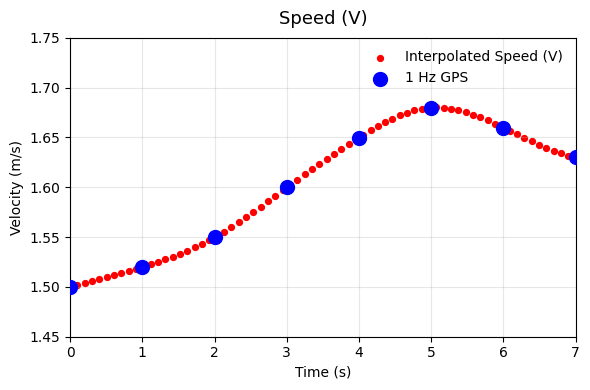

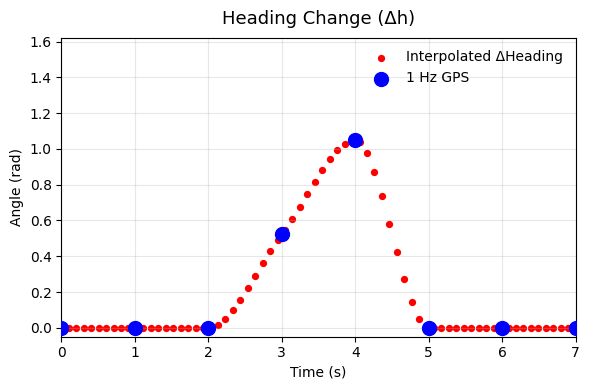

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, PchipInterpolator

# -----------------------------
# 1Hz GPS time points
# -----------------------------
t_gps = np.arange(0, 8, 1)  # 0..7 s (1 Hz)

# -----------------------------
# GPS-derived labels
# -----------------------------
# Speed: ~1.5–1.7 m/s gentle variation
v_gps = np.array([1.50, 1.52, 1.55, 1.60, 1.65, 1.68, 1.66, 1.63])

# Heading change (cumulative angle): 2–4 s → 90° (π/2 rad), then hold
dh_gps = np.zeros_like(t_gps, dtype=float)
dh_gps[2:5] = np.linspace(0, np.pi/3, 3)  # t=2,3,4: 0 → π/2
#dh_gps[5:] = dh_gps[4]                    # hold after t>=5 to avoid oscillation

# -----------------------------
# Interpolation grids
# -----------------------------
t_dense = np.linspace(0, 7, 70)  # 0.1 s (10 Hz)

# Speed: cubic is fine (smooth)
v_interp = interp1d(t_gps, v_gps, kind='cubic')(t_dense)

# Δh: use PCHIP (shape-preserving monotone) to avoid overshoot
pchip = PchipInterpolator(t_gps, dh_gps, extrapolate=True)
dh_interp = pchip(t_dense)

# (Optional) clip Δh range for extra safety (here 0..π/2)
dh_interp = np.clip(dh_interp, 0.0, np.pi/2)

# -----------------------------
# Plot separately
# -----------------------------
# 1) Speed
plt.figure(figsize=(6, 4))
plt.scatter(t_dense, v_interp, c='r', s=5, linewidth=3, label='Interpolated Speed (V)')
plt.scatter(t_gps, v_gps, c='b', s=100, zorder=5, label='1 Hz GPS')
plt.title("Speed (V)", fontsize=13, pad=10)
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.xlim(0, 7)
plt.ylim(1.45, 1.75)
plt.tight_layout()
plt.show()

# 2) Heading Change (Δh)
plt.figure(figsize=(6, 4))
plt.scatter(t_dense, dh_interp, color='r', s=5, linewidth=3, label='Interpolated ΔHeading')
plt.scatter(t_gps, dh_gps, color='b', s=100, zorder=5, label='1 Hz GPS')
plt.title("Heading Change (Δh)", fontsize=13, pad=10)
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.xlim(0, 7)
plt.ylim(-0.05, np.pi/2 + 0.05)
plt.tight_layout()
plt.show()
